# Setup

In [1]:
# Installing necessary libraries
!pip install gymnasium
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
# Loading all libraries
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Rye Microgrid Dataset

In [3]:
rye_microgrid_data = pd.read_csv('train.csv') # Load the dataset
rye_microgrid_data

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-3.2,93.1,-4.2,4.8,231.2,-3.1,91.6,-4.3,6.0,238.3
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-3.5,94.1,-4.3,4.9,224.9,-3.3,92.1,-4.4,6.2,231.8
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-3.6,93.0,-4.6,4.7,224.5,-3.3,90.6,-4.6,6.0,231.7
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-3.7,92.1,-4.8,4.5,222.8,-3.4,89.5,-4.9,5.8,231.1


In [4]:
rye_microgrid_data.columns

Index(['time', 'pv_production', 'wind_production', 'consumption',
       'spot_market_price', 'precip_1h:mm', 'precip_type:idx',
       'prob_precip_1h:p', 'clear_sky_rad:W', 'clear_sky_energy_1h:J',
       'diffuse_rad:W', 'diffuse_rad_1h:Wh', 'direct_rad:W',
       'direct_rad_1h:Wh', 'global_rad:W', 'global_rad_1h:Wh',
       'sunshine_duration_1h:min', 'sun_azimuth:d', 'sun_elevation:d',
       'low_cloud_cover:p', 'medium_cloud_cover:p', 'high_cloud_cover:p',
       'total_cloud_cover:p', 'effective_cloud_cover:p', 'temp',
       'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d'],
      dtype='object')

In [5]:
rye_microgrid_data.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9.515000e+03,9515.000000,...,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.00000,9515.000000
mean,7.654312,21.254382,20.262091,0.127386,0.066322,0.039096,3.312181,144.807325,5.213013e+05,38.549511,...,5.729207,76.279443,1.591088,4.283847,195.021703,5.633558,74.844782,1.220410,5.11671,198.633568
std,15.673519,38.225468,8.311275,0.125292,0.353434,0.239879,10.585675,232.985222,8.366789e+05,59.636149,...,6.927206,13.792720,6.265550,2.241726,81.361187,6.836455,14.001831,6.255477,2.67242,81.089361
min,0.000000,-582.200000,0.048396,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-14.800000,23.400000,-16.300000,0.100000,0.100000,-14.600000,22.300000,-16.600000,0.10000,0.300000
25%,0.000000,-0.260000,14.757704,0.044375,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,1.200000,67.400000,-2.700000,2.500000,134.100000,1.000000,65.900000,-3.100000,3.00000,142.950000
50%,0.000000,2.370000,18.817098,0.090390,0.000000,0.000000,1.000000,0.000000,3.637200e+03,0.000000,...,4.600000,78.400000,1.200000,4.000000,190.400000,4.500000,76.800000,0.900000,4.90000,192.300000
75%,6.411375,26.040000,23.716080,0.165970,0.000000,0.000000,1.000000,220.800000,7.768631e+05,63.900000,...,10.200000,87.100000,6.400000,5.600000,265.500000,10.100000,85.700000,6.000000,6.70000,267.700000
max,79.855834,225.500000,70.366622,1.140590,6.220000,3.000000,95.000000,834.800000,3.004661e+06,320.200000,...,29.700000,100.000000,17.000000,15.300000,359.900000,29.600000,100.000000,16.500000,17.40000,359.700000


In [6]:
# Parse time column
df = rye_microgrid_data.copy()
df['time'] = pd.to_datetime(df['time'])

# Extract hour of day
df['hour']   = df['time'].dt.hour

# Build sin/cos features
df['h_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['h_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day-of-week
df['dow']   = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

# Forecasting- Solar and Wind Production

Old Code

In [ ]:
# class TimeSeriesDataset(Dataset):
#   """
#     Custom PyTorch Dataset class for making Tensor Dataset for Solar/Wind/Load Data
#   """
#   def __init__(self, X, y):
#     self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
#     self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

#   def __len__(self):
#     return len(self.X)

#   def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# # Helper function to create the datasets
# def create_dataset(data, scaler, input_length=10, TEST_SIZE=0.2, BATCH_SIZE=32):
#   # scale the data
#   data = scaler.fit_transform(data.to_frame())
#   data = data.flatten()
#   X, y = [], []
#   # Create samples of input_length previous timestamp data points and predict next data point
#   for i in range(len(data)-input_length):
#     X.append(data[i:i+input_length])
#     y.append(data[i+input_length])

#   # Convert to numpy
#   X = np.array(X)
#   y = np.array(y)

#   # Split the data
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)

#   # Create datasets
#   train_dataset = TimeSeriesDataset(X_train, y_train)
#   test_dataset = TimeSeriesDataset(X_test, y_test)

#   # Create dataloaders
#   train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#   test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#   return train_loader, test_loader, scaler

In [ ]:
# # Helper function to create the datasets
# def create_dataset_morecols(data, datatype, scaler, input_length=10, TEST_SIZE=0.2, BATCH_SIZE=32):
#   # scale the data
#   data = scaler.fit_transform(data)
#   X, y = [], []
#   # Create samples of input_length previous timestamp data points and predict next data point
#   for i in range(len(data)-input_length):
#     X.append(data[i:i+input_length])
#     y.append(data[i+input_length, 0])

#   # Convert to numpy
#   X = np.array(X)
#   y = np.array(y)

#   # Split the data
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)

#   # Create datasets
#   train_dataset = TimeSeriesDataset2(X_train, y_train)
#   test_dataset = TimeSeriesDataset2(X_test, y_test)

#   # Create dataloaders
#   train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#   test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#   return train_loader, test_loader, scaler

Transformer Architecture (Kenny's Version)

In [7]:
class TimeSeriesDataset(Dataset):
    """
    Custom PyTorch Dataset class for Solar/Wind/Load Data
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
def create_dataset(data, scaler, input_length=24, test_size=0.2, batch_size=32):
    # data: pd.Series or pd.DataFrame of shape (T,) or (T, F)
    arr = scaler.fit_transform(data.values if isinstance(data, pd.DataFrame) else data.to_frame())
    # arr is now shape (T, F) even if F==1

    X, y = [], []
    for i in range(len(arr) - input_length):
        X.append(arr[i : i + input_length])         # shape (input_length, F)
        y.append(arr[i + input_length, 0])          # predict only first column

    X = np.stack(X)  # (N, input_length, F)
    y = np.array(y)  # (N,)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    train_ds = TimeSeriesDataset(X_train, y_train)
    test_ds  = TimeSeriesDataset(X_test,  y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, scaler

In [ ]:
# Loading forecasting data- solar, wind and load consumption data
solar_prod_data = df[['pv_production', 'hour', 'month', 'dow']]
# Creating the scalers
solar_scaler = MinMaxScaler()

# Create individual data loaders
solar_train_loader, solar_test_loader, solar_scaler = create_dataset(data=solar_prod_data, scaler=solar_scaler, input_length=10)

In [10]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_layers, dropout, window_size):
        super(TimeSeriesTransformer, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                  dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]
        x = self.encoder(x)  # [batch_size, seq_len, d_model]
        x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
        x = self.transformer_encoder(x)
        x = x[:, -1, :]  # Use the last sequence element for prediction
        x = self.decoder(x)  # [batch_size, output_dim]
        return x

In [11]:
# Helper function to evaluate Transformer model on GPU
def evaluate_model(model, scaler, test_loader, datatype):
    model.eval()
    prediction = []
    actual = []
    baseline_preds = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            pred = torch.clamp(pred, min=0)

            # move to CPU before converting to numpy
            pred_cpu = pred.squeeze(-1).cpu().numpy()
            y_cpu    = y.squeeze(-1).cpu().numpy()

            b = X[:,:,0].mean(dim=1)
            baseline_preds.extend(b.cpu().numpy())

            prediction.extend(pred_cpu)
            actual.extend(y_cpu)

    # inverse‐scale back to original units
    # prediction = scaler.inverse_transform(np.array(prediction).reshape(-1, 1)).squeeze()
    # actual     = scaler.inverse_transform(np.array(actual).reshape(-1, 1)).squeeze()

    mse = mean_squared_error(actual, prediction)
    print(f"Test MSE: {mse:.4f}")

    # Full‐series plot
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(prediction, label="Predicted", linestyle="--")
    plt.plot(baseline_preds,   label="Baseline",    linestyle="--")
    plt.xlabel("Time Step")
    plt.ylabel(f"{datatype} Generation")
    plt.title(f"Predicted vs Actual {datatype} Generation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Zoomed‐in view
    plt.figure(figsize=(10, 4))
    plt.plot(actual[:50], label="Actual")
    plt.plot(prediction[:50], label="Predicted", linestyle="--")
    plt.plot(baseline_preds[:50],   label="Baseline",    linestyle="--")
    plt.title("Zoomed-in view (first 50 samples)")
    plt.legend()
    plt.show()


In [ ]:
# Model Hyperparameters
INPUT_DIM = 4
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [ ]:
# Creating Solar Model
solar_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
solar_criterion = nn.MSELoss()
solar_optim = optim.Adam(solar_model.parameters(), lr=1e-3)

In [ ]:
# Train Solar Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
solar_model.to(device)
solar_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in solar_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        solar_optim.zero_grad()
        output = solar_model(batch_X)
        loss = solar_criterion(output, batch_y)
        loss.backward()
        solar_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(solar_train_loader):.4f}")


Epoch 1, Loss: 0.0458
Epoch 2, Loss: 0.0078
Epoch 3, Loss: 0.0071
Epoch 4, Loss: 0.0070
Epoch 5, Loss: 0.0062
Epoch 6, Loss: 0.0062
Epoch 7, Loss: 0.0062
Epoch 8, Loss: 0.0060
Epoch 9, Loss: 0.0059
Epoch 10, Loss: 0.0058
Epoch 11, Loss: 0.0060
Epoch 12, Loss: 0.0059
Epoch 13, Loss: 0.0057
Epoch 14, Loss: 0.0058
Epoch 15, Loss: 0.0059
Epoch 16, Loss: 0.0058
Epoch 17, Loss: 0.0056
Epoch 18, Loss: 0.0057
Epoch 19, Loss: 0.0057
Epoch 20, Loss: 0.0057
Epoch 21, Loss: 0.0057
Epoch 22, Loss: 0.0055
Epoch 23, Loss: 0.0055
Epoch 24, Loss: 0.0054
Epoch 25, Loss: 0.0053
Epoch 26, Loss: 0.0055
Epoch 27, Loss: 0.0058
Epoch 28, Loss: 0.0054
Epoch 29, Loss: 0.0056
Epoch 30, Loss: 0.0053
Epoch 31, Loss: 0.0053
Epoch 32, Loss: 0.0055
Epoch 33, Loss: 0.0054
Epoch 34, Loss: 0.0054
Epoch 35, Loss: 0.0052
Epoch 36, Loss: 0.0055
Epoch 37, Loss: 0.0053
Epoch 38, Loss: 0.0054
Epoch 39, Loss: 0.0052
Epoch 40, Loss: 0.0053
Epoch 41, Loss: 0.0053
Epoch 42, Loss: 0.0053
Epoch 43, Loss: 0.0053
Epoch 44, Loss: 0.00

Test MSE: 0.0007


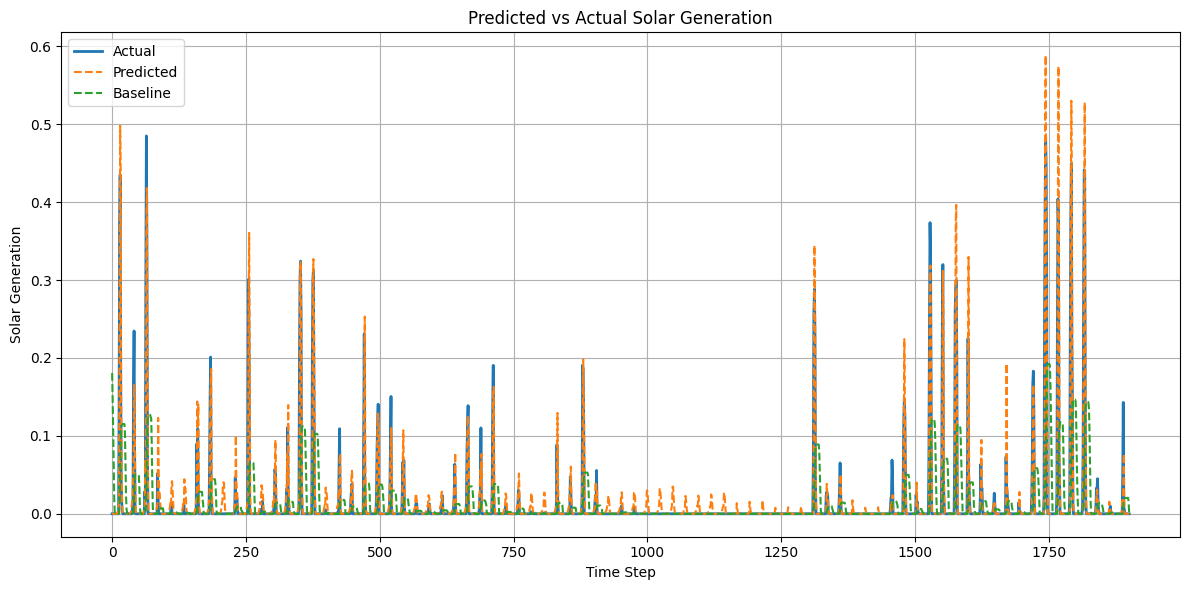

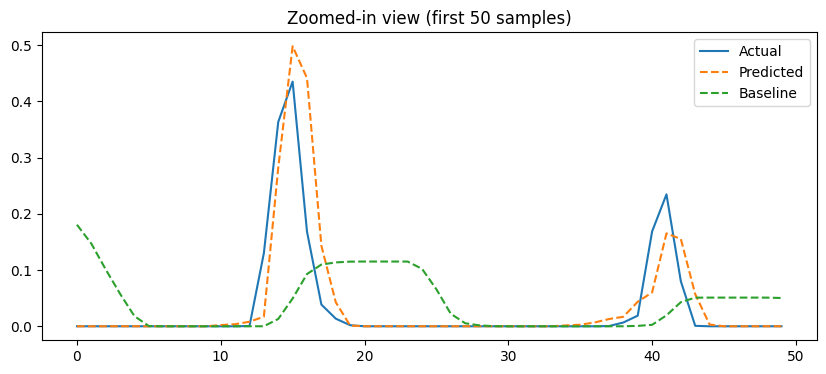

In [ ]:
evaluate_model(solar_model, solar_scaler, solar_test_loader, "Solar")

In [ ]:
# Model Hyperparameters
INPUT_DIM = 4
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [ ]:
wind_prod_data = df[['wind_production', 'hour', 'month', 'dow']]
wind_scaler = MinMaxScaler()
wind_train_loader, wind_test_loader, wind_scaler = create_dataset(data=wind_prod_data, scaler=wind_scaler, input_length=10)

In [ ]:
# Creating Wind Model
wind_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
wind_criterion = nn.MSELoss()
wind_optim = optim.Adam(wind_model.parameters(), lr=1e-3)

In [ ]:
# Train Wind Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wind_model.to(device)
wind_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in wind_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        wind_optim.zero_grad()
        output = wind_model(batch_X)
        loss = wind_criterion(output, batch_y)
        loss.backward()
        wind_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(wind_train_loader):.4f}")

Epoch 1, Loss: 0.0552
Epoch 2, Loss: 0.0037
Epoch 3, Loss: 0.0023
Epoch 4, Loss: 0.0014
Epoch 5, Loss: 0.0013
Epoch 6, Loss: 0.0011
Epoch 7, Loss: 0.0010
Epoch 8, Loss: 0.0010
Epoch 9, Loss: 0.0010
Epoch 10, Loss: 0.0010
Epoch 11, Loss: 0.0009
Epoch 12, Loss: 0.0008
Epoch 13, Loss: 0.0009
Epoch 14, Loss: 0.0009
Epoch 15, Loss: 0.0009
Epoch 16, Loss: 0.0010
Epoch 17, Loss: 0.0009
Epoch 18, Loss: 0.0009
Epoch 19, Loss: 0.0009
Epoch 20, Loss: 0.0009
Epoch 21, Loss: 0.0009
Epoch 22, Loss: 0.0009
Epoch 23, Loss: 0.0009
Epoch 24, Loss: 0.0009
Epoch 25, Loss: 0.0008
Epoch 26, Loss: 0.0009
Epoch 27, Loss: 0.0008
Epoch 28, Loss: 0.0008
Epoch 29, Loss: 0.0009
Epoch 30, Loss: 0.0008
Epoch 31, Loss: 0.0008
Epoch 32, Loss: 0.0008
Epoch 33, Loss: 0.0009
Epoch 34, Loss: 0.0009
Epoch 35, Loss: 0.0008
Epoch 36, Loss: 0.0008
Epoch 37, Loss: 0.0008
Epoch 38, Loss: 0.0007
Epoch 39, Loss: 0.0009
Epoch 40, Loss: 0.0008
Epoch 41, Loss: 0.0008
Epoch 42, Loss: 0.0007
Epoch 43, Loss: 0.0008
Epoch 44, Loss: 0.00

Test MSE: 0.0010


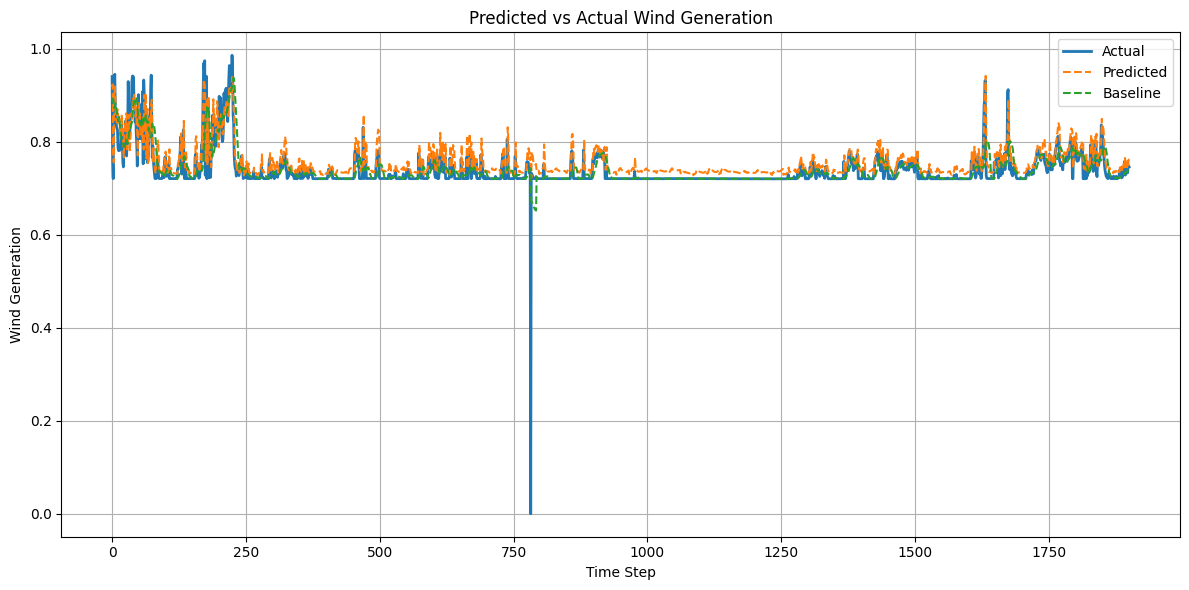

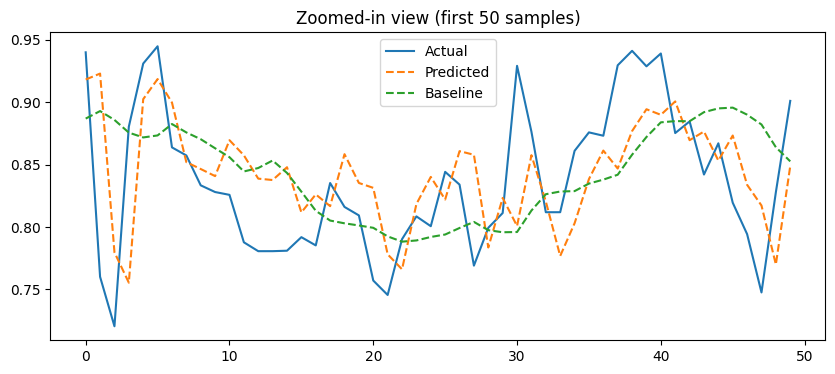

In [ ]:
evaluate_model(wind_model, wind_scaler, wind_test_loader, "Wind")

Only Generation Data

In [9]:
# Loading forecasting data- solar, wind and load consumption data
solar_prod_data = df[['pv_production']]
# Creating the scalers
solar_scaler = MinMaxScaler()

# Create individual data loaders
solar_train_loader, solar_test_loader, solar_scaler = create_dataset(data=solar_prod_data, scaler=solar_scaler, input_length=10)

In [14]:
# Model Hyperparameters
INPUT_DIM = 1
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [15]:
# Creating Solar Model
solar_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
solar_criterion = nn.MSELoss()
solar_optim = optim.Adam(solar_model.parameters(), lr=1e-3)

In [16]:
# Train Solar Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
solar_model.to(device)
solar_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in solar_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        solar_optim.zero_grad()
        output = solar_model(batch_X)
        loss = solar_criterion(output, batch_y)
        loss.backward()
        solar_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(solar_train_loader):.4f}")


Epoch 1, Loss: 0.0788
Epoch 2, Loss: 0.0096
Epoch 3, Loss: 0.0084
Epoch 4, Loss: 0.0077
Epoch 5, Loss: 0.0074
Epoch 6, Loss: 0.0072
Epoch 7, Loss: 0.0072
Epoch 8, Loss: 0.0071
Epoch 9, Loss: 0.0071
Epoch 10, Loss: 0.0074
Epoch 11, Loss: 0.0072
Epoch 12, Loss: 0.0069
Epoch 13, Loss: 0.0068
Epoch 14, Loss: 0.0071
Epoch 15, Loss: 0.0068
Epoch 16, Loss: 0.0069
Epoch 17, Loss: 0.0068
Epoch 18, Loss: 0.0068
Epoch 19, Loss: 0.0069
Epoch 20, Loss: 0.0068
Epoch 21, Loss: 0.0068
Epoch 22, Loss: 0.0068
Epoch 23, Loss: 0.0069
Epoch 24, Loss: 0.0066
Epoch 25, Loss: 0.0067
Epoch 26, Loss: 0.0066
Epoch 27, Loss: 0.0068
Epoch 28, Loss: 0.0066
Epoch 29, Loss: 0.0066
Epoch 30, Loss: 0.0066
Epoch 31, Loss: 0.0065
Epoch 32, Loss: 0.0067
Epoch 33, Loss: 0.0065
Epoch 34, Loss: 0.0065
Epoch 35, Loss: 0.0065
Epoch 36, Loss: 0.0068
Epoch 37, Loss: 0.0064
Epoch 38, Loss: 0.0064
Epoch 39, Loss: 0.0064
Epoch 40, Loss: 0.0066
Epoch 41, Loss: 0.0064
Epoch 42, Loss: 0.0065
Epoch 43, Loss: 0.0064
Epoch 44, Loss: 0.00

Test MSE: 0.0014


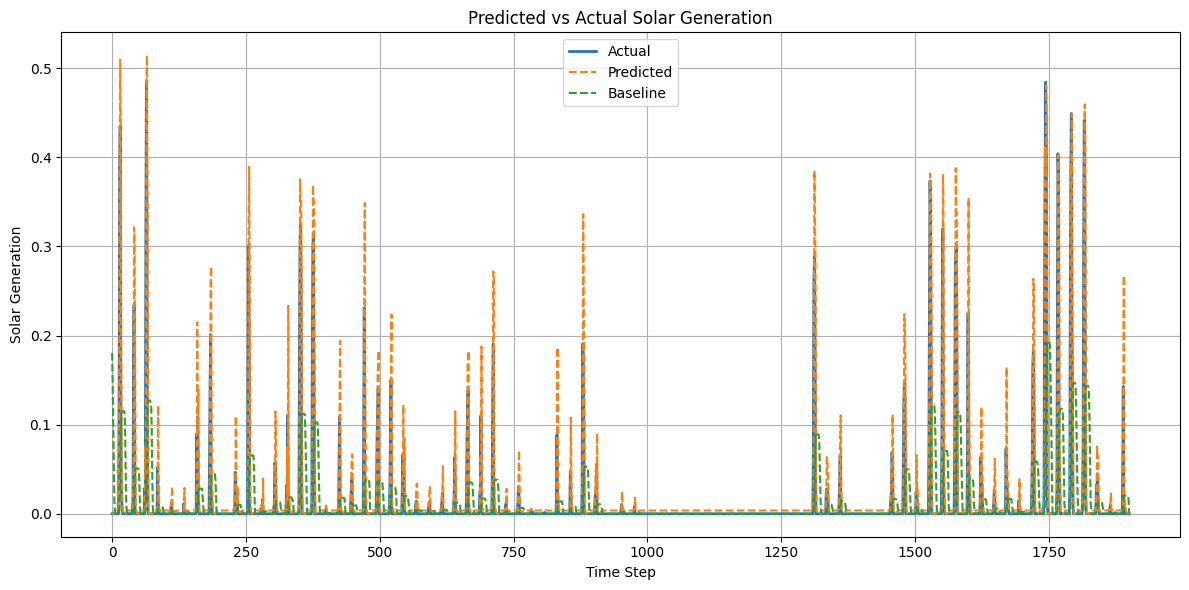

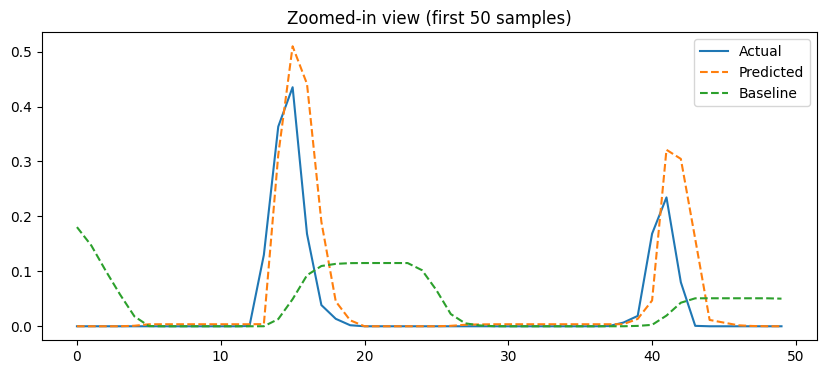

In [17]:
evaluate_model(solar_model, solar_scaler, solar_test_loader, "Solar")

In [18]:
# Loading forecasting data- solar, wind and load consumption data
wind_prod_data = df[['wind_production']]
# Creating the scalers
wind_scaler = MinMaxScaler()

# Create individual data loaders
wind_train_loader, wind_test_loader, wind_scaler = create_dataset(data=wind_prod_data, scaler=wind_scaler, input_length=10)

In [19]:
# Model Hyperparameters
INPUT_DIM = 1
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [20]:
# Creating Wind Model
wind_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
wind_criterion = nn.MSELoss()
wind_optim = optim.Adam(wind_model.parameters(), lr=1e-3)

In [21]:
# Train Wind Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wind_model.to(device)
wind_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in wind_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        wind_optim.zero_grad()
        output = wind_model(batch_X)
        loss = wind_criterion(output, batch_y)
        loss.backward()
        wind_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(wind_train_loader):.4f}")


Epoch 1, Loss: 0.0425
Epoch 2, Loss: 0.0029
Epoch 3, Loss: 0.0013
Epoch 4, Loss: 0.0011
Epoch 5, Loss: 0.0010
Epoch 6, Loss: 0.0010
Epoch 7, Loss: 0.0008
Epoch 8, Loss: 0.0008
Epoch 9, Loss: 0.0009
Epoch 10, Loss: 0.0008
Epoch 11, Loss: 0.0008
Epoch 12, Loss: 0.0009
Epoch 13, Loss: 0.0008
Epoch 14, Loss: 0.0009
Epoch 15, Loss: 0.0009
Epoch 16, Loss: 0.0008
Epoch 17, Loss: 0.0008
Epoch 18, Loss: 0.0008
Epoch 19, Loss: 0.0008
Epoch 20, Loss: 0.0009
Epoch 21, Loss: 0.0009
Epoch 22, Loss: 0.0008
Epoch 23, Loss: 0.0008
Epoch 24, Loss: 0.0008
Epoch 25, Loss: 0.0007
Epoch 26, Loss: 0.0008
Epoch 27, Loss: 0.0009
Epoch 28, Loss: 0.0008
Epoch 29, Loss: 0.0008
Epoch 30, Loss: 0.0008
Epoch 31, Loss: 0.0008
Epoch 32, Loss: 0.0008
Epoch 33, Loss: 0.0008
Epoch 34, Loss: 0.0008
Epoch 35, Loss: 0.0008
Epoch 36, Loss: 0.0008
Epoch 37, Loss: 0.0008
Epoch 38, Loss: 0.0008
Epoch 39, Loss: 0.0008
Epoch 40, Loss: 0.0008
Epoch 41, Loss: 0.0008
Epoch 42, Loss: 0.0008
Epoch 43, Loss: 0.0007
Epoch 44, Loss: 0.00

Test MSE: 0.0007


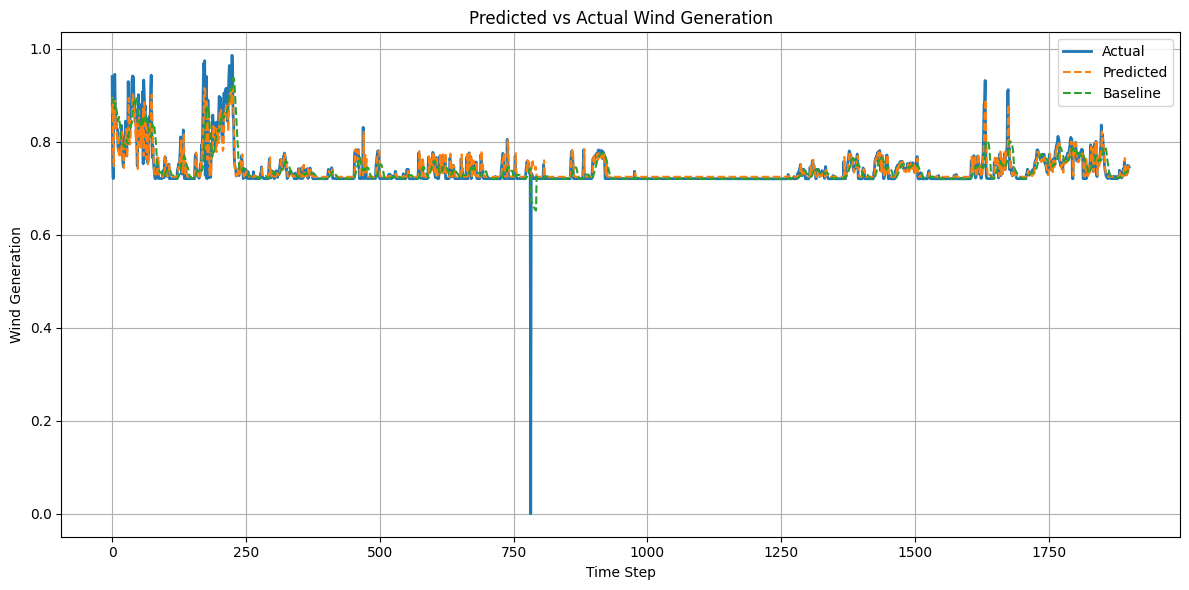

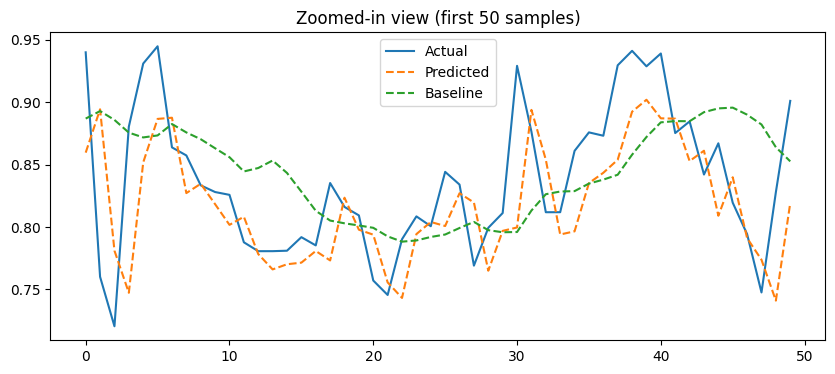

In [23]:
evaluate_model(wind_model, wind_scaler, wind_test_loader, "Wind")

LSTM Version

In [25]:
# Loading forecasting data- solar, wind and load consumption data
solar_prod_data = df[['pv_production', 'hour', 'dow', 'month']]
# Creating the scalers
solar_scaler = MinMaxScaler()

# Create individual data loaders
solar_train_loader, solar_test_loader, solar_scaler = create_dataset(data=solar_prod_data, scaler=solar_scaler, input_length=10)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedLSTMForecastingModel(nn.Module):
    """
    Bidirectional LSTM + Attention + MLP head for one-step forecasting.
    Input: (batch, seq_len, input_dim)
    Output: (batch, 1)
    """
    def __init__(self,
                 input_dim:   int = 3,
                 hidden_dim:  int = 128,
                 num_layers:  int = 2,
                 dropout:     float = 0.2,
                 attention_dim: int = 64,
                 output_dim:  int = 1):
        super().__init__()

        # 1) Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )

        # 2) Self‐attention over the time axis
        self.attn_q = nn.Linear(hidden_dim * 2, attention_dim, bias=False)
        self.attn_k = nn.Linear(hidden_dim * 2, attention_dim, bias=False)
        self.attn_v = nn.Linear(hidden_dim * 2, attention_dim, bias=False)

        # 3) MLP head
        self.fc1 = nn.Linear(attention_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch, seq_len, input_dim)
        returns: (batch, output_dim)
        """
        # — LSTM
        lstm_out, _ = self.lstm(x)               # (batch, seq_len, hidden_dim*2)

        # — Attention scores
        Q = self.attn_q(lstm_out)                # (batch, seq_len, attn_dim)
        K = self.attn_k(lstm_out)                # (batch, seq_len, attn_dim)
        V = self.attn_v(lstm_out)                # (batch, seq_len, attn_dim)

        # scaled dot‐product attention
        scores = torch.matmul(Q, K.transpose(1, 2)) / (Q.size(-1) ** 0.5)
        weights = F.softmax(scores, dim=-1)      # (batch, seq_len, seq_len)

        ctx = torch.matmul(weights, V)           # (batch, seq_len, attn_dim)

        # — Pool across time (mean + max)
        mean_ctx = ctx.mean(dim=1)               # (batch, attn_dim)
        max_ctx, _ = ctx.max(dim=1)              # (batch, attn_dim)
        attn_out = mean_ctx + max_ctx            # (batch, attn_dim)

        # — MLP head
        h = self.fc1(attn_out)                   # (batch, hidden_dim)
        h = self.norm1(h)
        h = F.relu(h)
        h = self.drop1(h)

        out = self.fc2(h)                        # (batch, output_dim)
        return out


[Epoch 010] Train MSE: 0.0064
[Epoch 020] Train MSE: 0.0059
[Epoch 030] Train MSE: 0.0056
[Epoch 040] Train MSE: 0.0055
[Epoch 050] Train MSE: 0.0054
[Epoch 060] Train MSE: 0.0053
[Epoch 070] Train MSE: 0.0053
[Epoch 080] Train MSE: 0.0054
[Epoch 090] Train MSE: 0.0053
[Epoch 100] Train MSE: 0.0053
Test MSE: 0.0010


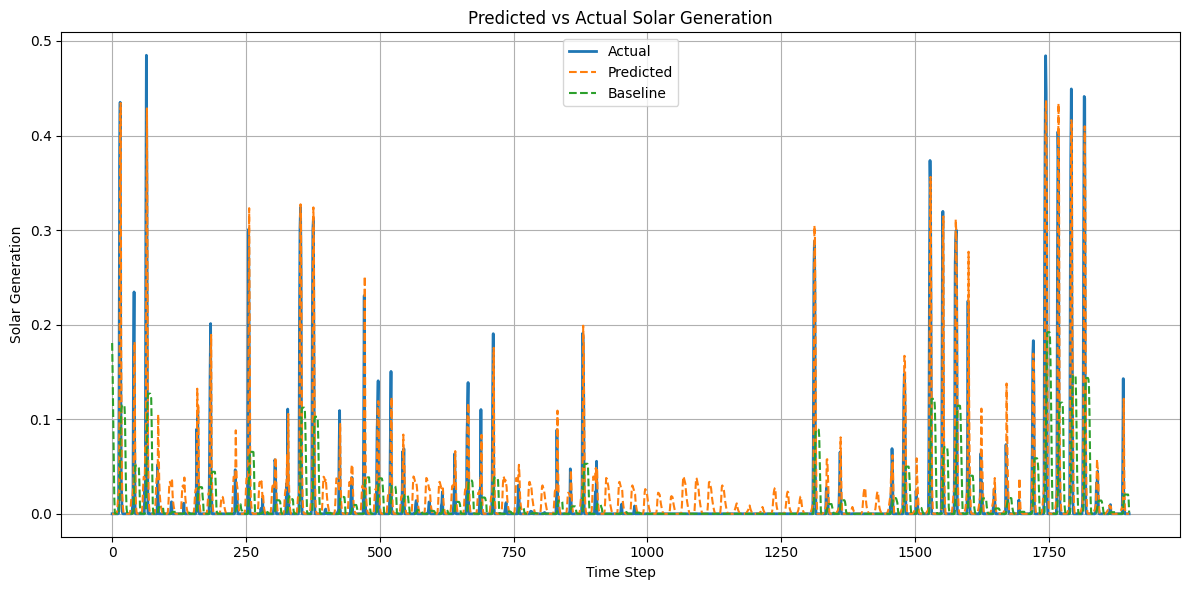

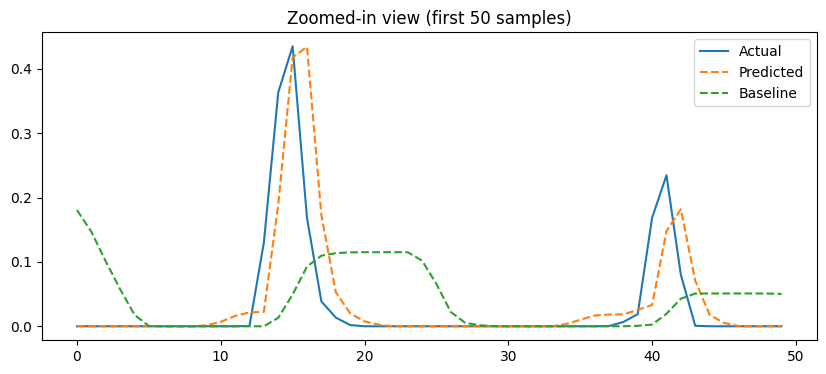

In [26]:
import torch.optim as optim
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
INPUT_DIM   = 4
HIDDEN_DIM  = 64
NUM_LAYERS  = 2
DROPOUT     = 0.1
OUTPUT_DIM  = 1
LR          = 1e-3
EPOCHS      = 100

# 1) Instantiate
model     = ImprovedLSTMForecastingModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, OUTPUT_DIM)
model     = model.to(device)
criterion = nn.MSELoss()
optim     = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# 2) Training loop
for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for X, y in solar_train_loader:   # or wind_train_loader
        X, y = X.to(device), y.to(device)
        optim.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        epoch_loss += loss.item() * X.size(0)
    epoch_loss /= len(solar_train_loader.dataset)
    if epoch % 10 == 0:
        print(f"[Epoch {epoch:03d}] Train MSE: {epoch_loss:.4f}")

# 3) Evaluation (reuse previous evaluate_model, passing in `model` & `device`)
evaluate_model(model, solar_scaler, solar_test_loader, "Solar")


In [27]:
# Loading forecasting data- solar, wind and load consumption data
wind_prod_data = df[['wind_production', 'hour', 'dow', 'month']]
# Creating the scalers
wind_scaler = MinMaxScaler()

# Create individual data loaders
wind_train_loader, wind_test_loader, wind_scaler = create_dataset(data=wind_prod_data, scaler=wind_scaler, input_length=10)

[Epoch 010] Train MSE: 0.0032
[Epoch 020] Train MSE: 0.0012
[Epoch 030] Train MSE: 0.0009
[Epoch 040] Train MSE: 0.0008
[Epoch 050] Train MSE: 0.0008
[Epoch 060] Train MSE: 0.0008
[Epoch 070] Train MSE: 0.0007
[Epoch 080] Train MSE: 0.0007
[Epoch 090] Train MSE: 0.0008
[Epoch 100] Train MSE: 0.0007
Test MSE: 0.0007


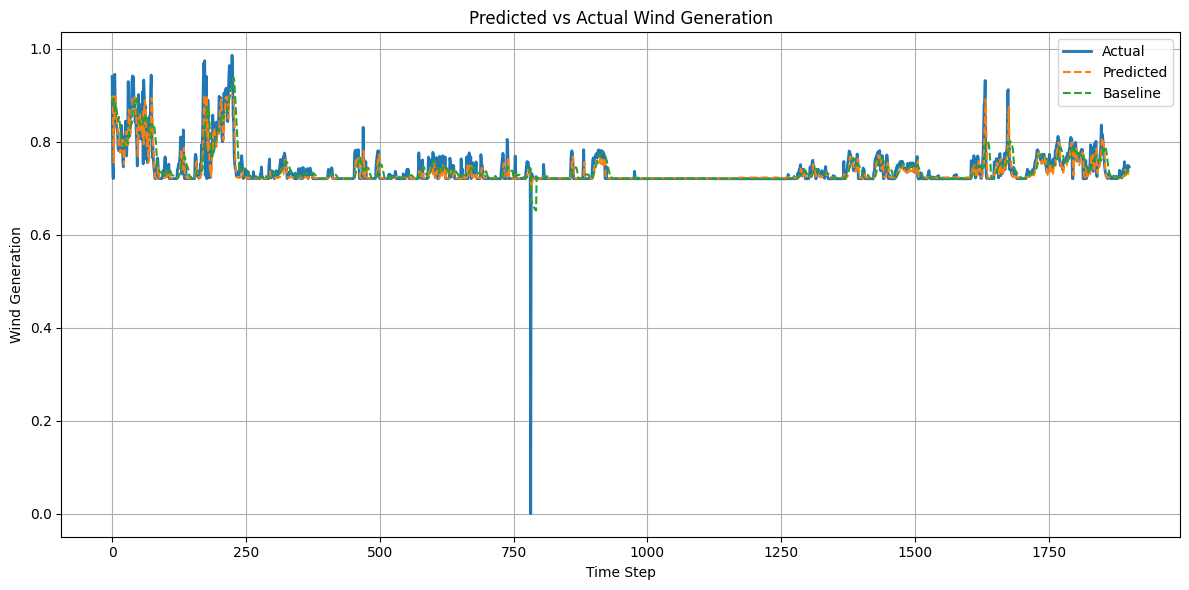

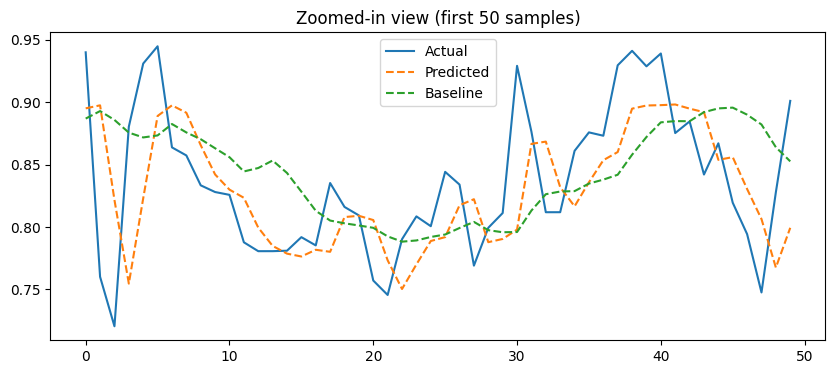

In [28]:
import torch.optim as optim
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
INPUT_DIM   = 4
HIDDEN_DIM  = 64
NUM_LAYERS  = 2
DROPOUT     = 0.1
OUTPUT_DIM  = 1
LR          = 1e-3
EPOCHS      = 100

# 1) Instantiate
model     = ImprovedLSTMForecastingModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, OUTPUT_DIM)
model     = model.to(device)
criterion = nn.MSELoss()
optim     = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# 2) Training loop
for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for X, y in wind_train_loader:   # or wind_train_loader
        X, y = X.to(device), y.to(device)
        optim.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        epoch_loss += loss.item() * X.size(0)
    epoch_loss /= len(wind_train_loader.dataset)
    if epoch % 10 == 0:
        print(f"[Epoch {epoch:03d}] Train MSE: {epoch_loss:.4f}")

# 3) Evaluation (reuse previous evaluate_model, passing in `model` & `device`)
evaluate_model(model, wind_scaler, wind_test_loader, "Wind")


# Old Environment

In [ ]:
# import gymnasium as gym
# import numpy as np
# from gymnasium import spaces

# class RyeMicrogridEnv(gym.Env):
#   """
#     Custom Microgrid Environment for Rye Microgrid
#   """
#   def __init__(self, data, num_days):
#     super(RyeMicrogridEnv, self).__init__()
#     # no of hours to simulate
#     self.num_hours = 24 * num_days
#     self.curr_hour = 0

#     # store all necessary data for Rye Microgrid
#     self.data = data

#     # setup battery
#     self.battery_max = 500
#     self.battery_power = 0.5 * self.battery_max

#     # State consists of PV, Wind, Battery, Load and Price
#     self.observation_space = spaces.Box(low=0, high=1, shape=(5,), dtype=np.float32)

#     # Action Space: 7 Actions described above
#     self.action_space = spaces.Discrete(7)

#     self.state = self._get_observation()

#   def _get_observation(self):
#     # Returns the state variables
#     curr_data = self.data.loc[self.curr_hour, ['pv_production', 'wind_production', 'consumption', 'spot_market_price']]

#     return np.array([curr_data['pv_production'], curr_data['wind_production'], self.battery_power, curr_data['consumption'], curr_data['spot_market_price']], dtype=np.float32)

#   def step(self, action):
#     # Unpack state
#     pv, wind, battery, load, price = self.state

#     # Set reward and done states
#     reward = 0
#     done = False
#     consumption = load
#     unmet = 0
#     purchased = 0
#     sold = 0

#     # Action Handling
#     if action == 0:
#       self.battery_power = min(self.battery_max, self.battery_power + pv + wind)
#       purchased = consumption
#       unmet = 0 # all energy purchased from grid
#       reward -= purchased * price
#     elif action == 1:
#       if pv + wind >= consumption:
#         unmet = 0 # all demand met
#         reward = 0
#         purchased = 0
#         self.battery_power = min(self.battery_max, self.battery_power + pv + wind - consumption)
#       else:
#         unmet = consumption - pv - wind
#         reward -= unmet * 100
#     elif action == 2:
#       if pv + wind >= consumption:
#         unmet = 0 # all demand met
#         reward -= 100
#         purchased = 0
#         self.battery_power = min(self.battery_max, self.battery_power + pv + wind - consumption)
#       else:
#         unmet = 0
#         purchased = consumption - pv - wind
#         reward -= purchased * price
#     elif action == 3:
#       if pv + wind >= consumption:
#         unmet = 0 # all demand met
#         reward = 0
#         purchased = 0
#       else:
#         if self.battery_power >= consumption - pv - wind:
#           unmet = 0
#           purchased = 0
#           self.battery_power -= consumption - pv - wind
#           reward -= 100 * int(self.battery_power < 0.5 * self.battery_max)
#         else:
#           unmet = consumption - pv - wind - self.battery_power
#           self.battery_power = 0
#           purchased = 0
#           reward -= 100 + 100 * unmet
#     elif action == 4:
#       if pv + wind >= consumption:
#         unmet = 0 # all demand met
#         reward -= 100
#         purchased = 0
#       else:
#         if self.battery_power >= consumption - pv - wind:
#           unmet = 0
#           purchased = 0
#           self.battery_power -= consumption - pv - wind
#           reward -= 100 * int(self.battery_power < 0.5 * self.battery_max)
#         else:
#           unmet = 0
#           purchased = consumption - pv - wind
#           reward -= purchased * price
#     elif action == 5:
#       if pv + wind >= consumption:
#         unmet = 0
#         sold = max(0, self.battery_power - 0.5 * self.battery_max)
#         self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
#         reward += sold * price * 0.4
#       else:
#         unmet = consumption - pv - wind
#         sold = max(0, self.battery_power - 0.5 * self.battery_max)
#         self.battery_power = max(self.battery_power, self.battery_power - 0.5 * self.battery_max)
#         reward += sold * price * 0.4 - unmet * 100
#     elif action == 6:
#       if self.battery_power >= consumption:
#         unmet = 0
#         sold = pv + wind
#         self.battery_power -= consumption
#         reward += sold * price * 0.4 - 100 * (self.battery_power < 0.5 * self.battery_max)
#       else:
#         unmet = consumption - self.battery_power
#         self.battery_power = 0
#         sold = pv + wind
#         reward += sold * price * 0.4 - unmet * 100 - 100

#     # Update state
#     self.curr_hour += 1
#     if self.curr_hour >= self.num_hours:
#         done = True

#     self.state = self._get_observation()
#     return self.state, reward, done, False, {
#         "sold": sold,
#         "unmet": unmet,
#         "purchased": purchased,
#         "battery": self.battery_power,
#         "price": price,
#         "load": load,
#         "pv": pv,
#         "wind": wind,
#         "action": action,
#         "hour": self.curr_hour,
#     }

#   def reset(self, seed=None, options=None):
#     # Reset important parameters
#     super().reset(seed=seed)
#     self.curr_hour = 0
#     self.battery_power = 0.5 * self.battery_max
#     self.state = self._get_observation()
#     return self.state, {}

# States:

The following are the states allowed for each of the grid components:

**Renewable:** \
           0- Store in Battery only \
           1- Use for Load/Battery \
           2- Sell to Grid \
**Battery:** \
         0- Charge/Idle State \
         1- Use for Load \
         2- Sell to Grid \
**Grid:** \
      0 - Disconnect \
      1- Connect (to Buy) \
      2- Connect (to Sell) \

**Legal Combinations allowed for the microgrid:** \
001, 100, 101, 110, 111, 122, 212

**Combined Actions:** \
Action 0- Renewable Charges Battery + Grid Connected to satisfy load \
Action 1- Renewable Satisfies Load + Battery Charging + Grid Disconnected \
Action 2- Renewable Satisfies Load + Battery Charging + Grid Connected \
Action 3- Renewable and Battery Satisfy Load + Grid Disconnected \
Action 4- Renewable and Battery Satisfy Load + Grid Connected \
Action 5- Renewable Satisfies Load + Battery sells excess to Grid
Action 6- Renewable Sells to Grid + Battery satisfies Load

# New Environment

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class RyeMicrogridEnv(gym.Env):
  """
    Custom Microgrid Environment for Rye Microgrid
  """
  def __init__(self, data, num_days):
    super(RyeMicrogridEnv, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.curr_hour = 0

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = 500
    self.battery_power = 0.5 * self.battery_max # starting at 50%
    self.charge_efficiency = 0.85 # how much power is actually drawn/stored (accounts for losses due to transmission)

    # State consists of PV, Wind, Battery, Load and Price
    self.observation_space = spaces.Box(
        low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
        high=np.array([80, 230, self.battery_max, 100, 2], dtype=np.float32), # max states taken from description of data
        dtype=np.float32
    )

    # Action Space: 7 Actions described above
    self.action_space = spaces.Discrete(7)

    self.state = self._get_observation()

  def _get_observation(self):
    # Returns the state variables
    curr_data = self.data.loc[self.curr_hour, ['pv_production', 'wind_production', 'consumption', 'spot_market_price']]

    return np.array([curr_data['pv_production'], curr_data['wind_production'], self.battery_power, curr_data['consumption'], curr_data['spot_market_price']], dtype=np.float32)

  def step(self, action):
    # Unpack state
    pv, wind, battery, load, price = self.state

    # Set reward and done states
    reward = 0 # total reward
    reward_buy = 0 # reward for buying from grid
    reward_sell = 0 # reward for selling to grid
    reward_renewable_use = 0 # reward for using renewable energy
    reward_unused_load = 0 # reward for unused load
    reward_grid_conn = 0 # reward for connecting/disconnecting to grid
    reward_buy_factor = 1 # buy factor
    reward_sell_factor = 0.6 # sell factor
    reward_renewable_use_factor = 0.8 # factor for using renewable energy
    reward_unused_load_factor = 100 # factor for unused load
    reward_grid_conn_factor = 0.5 # grid connection factor

    done = False # done state

    # Parameters to help visualization
    consumption = load
    unmet = 0
    purchased = 0
    sold = 0


    # Action Handling
    if action == 0: # Use Renewable to charge battery & buy from grid to satisfy load
      self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind))
      purchased = consumption
      unmet = 0 # all energy purchased from grid
      reward_buy -= purchased * price
      reward_grid_conn -= 5
      reward_renewable_use += (pv + wind) * price
    elif action == 1: # Use Renewable for Load while Battery is also charging and Grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_grid_conn += 5
        reward_renewable_use += (pv + wind) * price
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = consumption - pv - wind
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        reward_unused_load -= unmet * price
    elif action == 2: # Use Renewable for Load while Battery is charging and Grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = 0
        reward_renewable_use += (pv + wind) * price
        purchased = consumption - pv - wind
        reward_buy -= (consumption - pv - wind) * price
        reward_grid_conn -= 5
    elif action == 3: # Use both Battery & Renewable for Load while grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind)/self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn += 5
        else:
          unmet = consumption - pv - wind - self.battery_power
          self.battery_power = 0
          purchased = 0
          reward_renewable_use += (pv + wind) * price
          reward_unused_load -= unmet * price
          reward_grid_conn += 5
    elif action == 4: # Use both Battery & Renewable for Load while grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind) / self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
        else:
          unmet = 0
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
          purchased = consumption - pv - wind
          reward_buy -= purchased * price
    elif action == 5: # Use Renewable for Load and Battery to sell to Grid
      if pv + wind >= consumption:
        unmet = 0
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_renewable_use += (pv + wind) * price
      else:
        unmet = consumption - pv - wind
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_renewable_use += (pv + wind) * price
        reward_unused_load -= unmet * price
        reward_grid_conn -= 5
    elif action == 6: # Use Renewable to sell and Battery to load
      if self.battery_power >= consumption / self.charge_efficiency:
        unmet = 0
        sold = pv + wind
        self.battery_power -= consumption / self.charge_efficiency
        reward_sell += sold * price
        reward_grid_conn -= 5
      else:
        unmet = consumption - self.charge_efficiency * self.battery_power
        self.battery_power = 0
        sold = pv + wind
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_unused_load -= unmet * price

    # Update state
    self.curr_hour += 1
    if self.curr_hour >= self.num_hours:
        done = True

    # Calculate reward
    reward += reward_sell * reward_sell_factor + reward_unused_load * reward_unused_load_factor \
              + reward_grid_conn * reward_grid_conn_factor + reward_renewable_use * reward_renewable_use_factor \
              + reward_buy * reward_buy_factor
    # Calculate status for grid, battery, and renewable
    grid_status = "Connected"
    battery_status = "Discharge Mode"
    renewable_status = "Satisfy Load and Battery"
    if reward_grid_conn > 0:
      grid_status = "Island Mode"
    if action == 0 or action == 1 or action == 2:
      battery_status = "Charge/Idle Mode"
    if action == 5:
      battery_status = "Discharge Sell Mode"
    if action == 0:
      renewable_status = "Charge Battery only"
    elif action == 6:
      renewable_status = "Sell to Grid"

    # Update state
    self.state = self._get_observation()
    return self.state, reward, done, False, {
        "sold": sold,
        "unmet": unmet,
        "purchased": purchased,
        "battery": self.battery_power,
        "price": price,
        "load": load,
        "pv": pv,
        "wind": wind,
        "action": action,
        "hour": self.curr_hour,
        "grid_status": grid_status,
        "renewable_status": renewable_status,
        "battery_status": battery_status
    }

  def reset(self, seed=None, options=None):
    # Reset important parameters
    super().reset(seed=seed)
    self.curr_hour = 0
    self.battery_power = 0.5 * self.battery_max
    self.state = self._get_observation()
    return self.state, {}


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create and wrap environment
env = RyeMicrogridEnv(rye_microgrid_data, num_days=30)
vec_env = make_vec_env(lambda: env, n_envs=1)

# Train the PPO agent
model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=500000)


# Save the model
model.save("ppo_microgrid")

Using cuda device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
|    value_loss           | 3.5e+06      |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 720          |
|    ep_rew_mean          | -5.77e+04    |
| time/                   |              |
|    fps                  | 391          |
|    iterations           | 8            |
|    time_elapsed         | 41           |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0025757453 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.9         |
|    explained_variance   | 4.83e-06     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.45e+06     |
|    n_updates            | 70           |
|    policy_gradient_loss | -0.00496     |
|    value_loss           | 2.98e+06     |
---

In [ ]:
import matplotlib.pyplot as plt

def simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "wind": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 16))

    plt.subplot(4, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["wind"], label="Wind Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    # Map string statuses to numeric values for plotting
    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


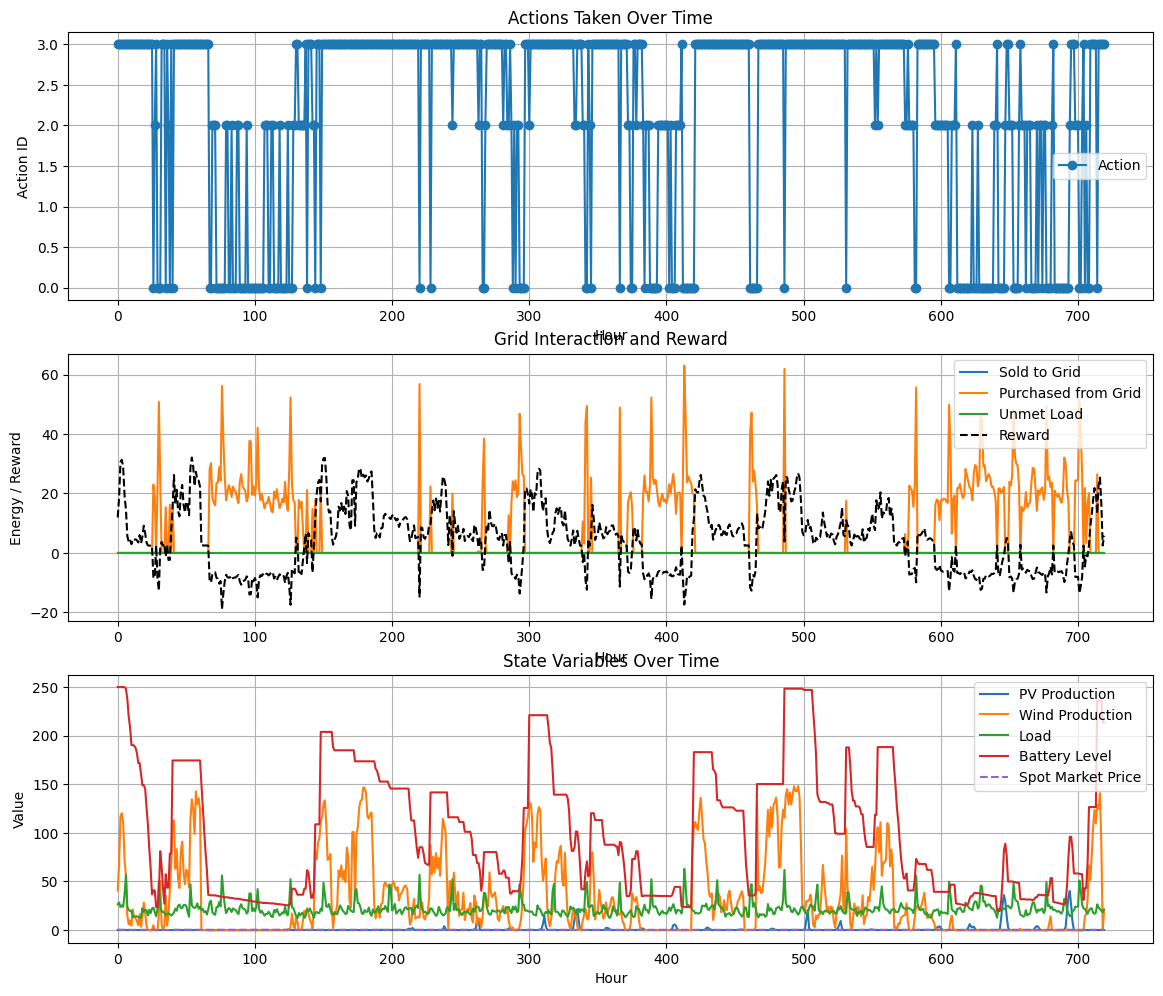

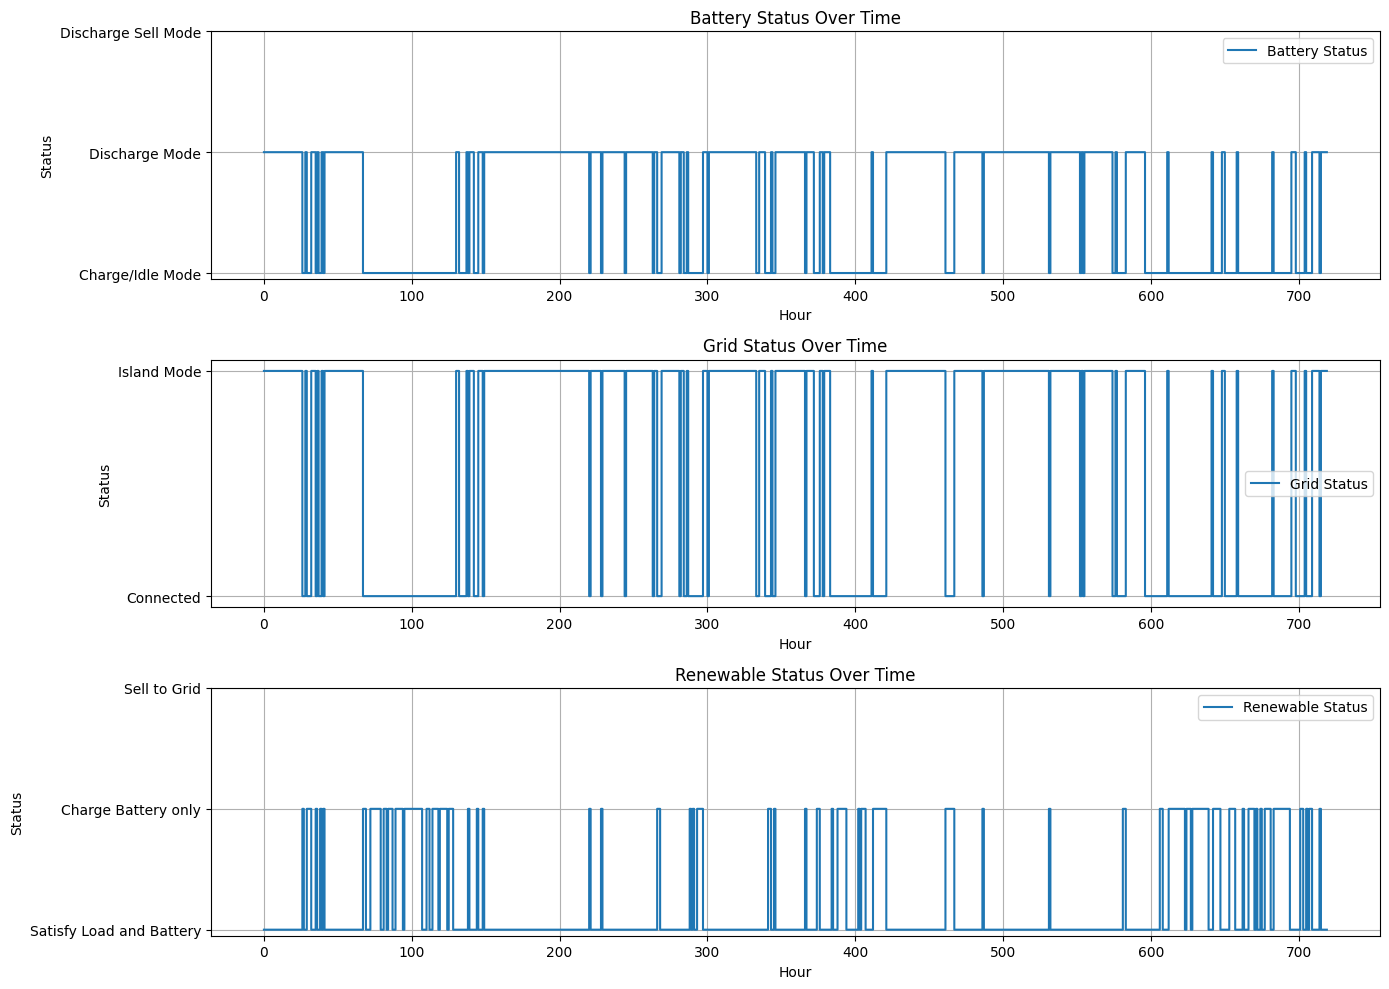

In [ ]:
simulate_and_plot(env, model, num_days_to_visualize=100)